In [29]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

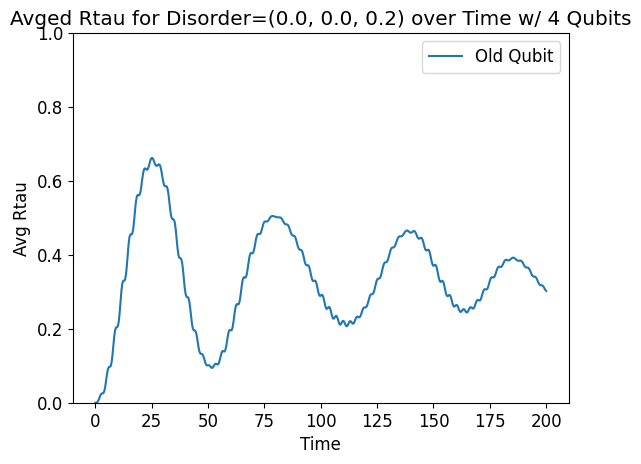

In [ ]:
wd = 0.6365091993031
wm = 1.0
tlist = np.linspace(0, 200, 500)
dz = 0.0
dy = 0.0
dx = 0.0
N = 4
reals = 1
amp = 0.1
args = {"A": amp, "omega": wd}
qargs = {"A": amp, "omega": wm}

tscar_dR = []
scar_dR = []
qubit_dR = []

H0_clean, H1, eigenvalues, eigenstates = get_qubit_ham(N)
for _ in range(reals):
    H0_dis, eigenvalues_dis, eigenstates_dis = getDisorderedQubitHam(H0_clean, N, ham_disorder=[dz, dy, dx], fixed_seed=True)

    H_dis = qt.QobjEvo([H0_dis, [H1, coeff]], args=qargs)
    psi_t = qt.sesolve(H_dis, eigenstates_dis[0], tlist, e_ops=[H0_dis])

    Rtau = np.real(psi_t.expect[0] - psi_t.expect[0][0]) / (eigenvalues_dis[-1] - eigenvalues_dis[0])
    scar_dR.append(Rtau)

scar_dR = np.array(scar_dR)
plotScar = np.mean(scar_dR, axis=0)

plt.plot(tlist, plotScar, label="Old Qubit")
plt.title(f"Avged Rtau for Disorder={dz, dy, dx} over Time w/ {N} Qubits")
plt.ylabel("Avg Rtau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.legend()
plt.show()